In [5]:
!pip install herbie-data cartopy metpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.8/306.8 kB 22.0 MB/s eta 0:00:00


In [68]:
from herbie import Herbie
from herbie.toolbox import EasyMap, pc
from herbie import paint
from herbie.models.hafs import Storms


import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import numpy as np

In [69]:
Storms().id_to_name

{'15s': 'ewetse',
 '28w': 'halong',
 '95s': 'invest',
 '91s': 'invest',
 '16p': 'sixteen',
 '90p': 'invest'}

In [64]:
H = Herbie(
    "2017-08-26 03:00:00",
    model="hrrr",
    product="prs",
    fxx=0,
)


✅ Found ┊ model=hrrr ┊ product=prs ┊ 2017-Aug-26 03:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


In [65]:
H.inventory().query("variable == 'UGRD'")


,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
6,7,3631071,4196546.0,3631071-4196546,2017-08-26 03:00:00,2017-08-26 03:00:00,UGRD,50 mb,anl,:UGRD:50 mb:anl
20,21,8443818,9012275.0,8443818-9012275,2017-08-26 03:00:00,2017-08-26 03:00:00,UGRD,75 mb,anl,:UGRD:75 mb:anl
34,35,12806495,13375101.0,12806495-13375101,2017-08-26 03:00:00,2017-08-26 03:00:00,UGRD,100 mb,anl,:UGRD:100 mb:anl
48,49,17352553,17925138.0,17352553-17925138,2017-08-26 03:00:00,2017-08-26 03:00:00,UGRD,125 mb,anl,:UGRD:125 mb:anl
62,63,22608814,23189711.0,22608814-23189711,2017-08-26 03:00:00,2017-08-26 03:00:00,UGRD,150 mb,anl,:UGRD:150 mb:anl
76,77,27900379,28483478.0,27900379-28483478,2017-08-26 03:00:00,2017-08-26 03:00:00,UGRD,175 mb,anl,:UGRD:175 mb:anl
90,91,33604231,34189112.0,33604231-34189112,2017-08-26 03:00:00,2017-08-26 03:00:00,UGRD,200 mb,anl,:UGRD:200 mb:anl
104,105,39683467,40277815.0,39683467-40277815,2017-08-26 03:00:00,2017-08-26 03:00:00,UGRD,225 mb,anl,:UGRD:225 mb:anl
118,119,45390435,45983241.0,45390435-45983241,2017-08-26 03:00:00,2017-08-26 03:00:00,UGRD,250 mb,anl,:UGRD:250 mb:anl
132,133,51201670,51793484.0,51201670-51793484,2017-08-26 03:00:00,2017-08-26 03:00:00,UGRD,275 mb,anl,:UGRD:275 mb:anl


In [66]:
ds = H.xarray(":UGRD:500 mb:anl")
ds


<xarray.Dataset> Size: 38MB
Dimensions:              (y: 1059, x: 1799)
Coordinates:
    time                 datetime64[ns] 8B 2017-08-26T03:00:00
    step                 timedelta64[ns] 8B 00:00:00
    isobaricInhPa        float64 8B 500.0
    latitude             (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude            (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    valid_time           datetime64[ns] 8B 2017-08-26T03:00:00
    gribfile_projection  object 8B None
Dimensions without coordinates: y, x
Data variables:
    u                    (y, x) float32 8MB -6.104 -6.104 -6.042 ... 6.521 6.458
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    model:                   hrrr
    product:                 prs
    description:             High-Resolution Rapid Refresh - CONUS
    remote_grib:             https://noaa-hrrr-bdp-pds.s3.amazonaws.com/hrrr....
    local_grib:              /root/data/hrrr/20170826/subset_bfefe1a8__hrrr.t...
    search:                  :UGRD:500 mb:anl

AttributeError: 'Dataset' object has no attribute 't'

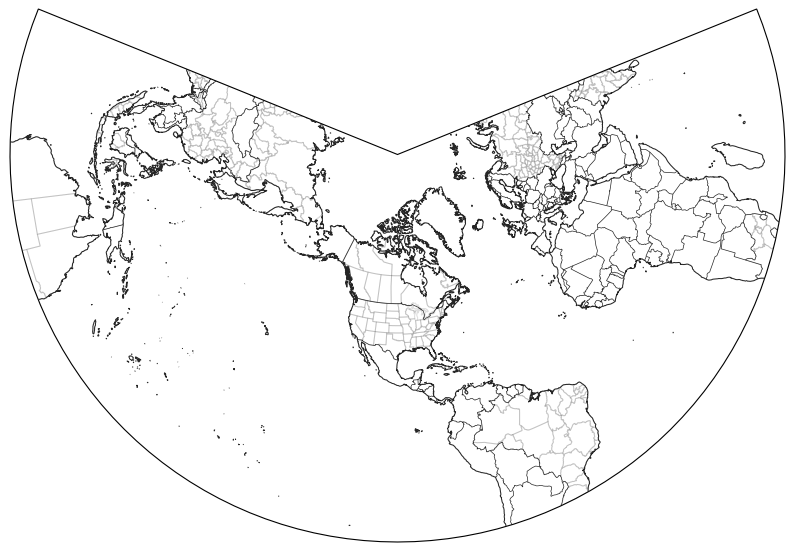

In [67]:
ax = EasyMap("50m", crs=ds.herbie.crs, figsize=[10, 8]).BORDERS().STATES().ax

p = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    ds.t - 273.15,
    transform=pc,
    **paint.NWSTemperature.kwargs2,
)
plt.colorbar(
    p,
    ax=ax,
    orientation="horizontal",
    pad=0.01,
    shrink=0.8,
    **paint.NWSTemperature.cbar_kwargs2,
)

ax.set_title(
    f"{ds.model.upper()}: {H.product_description}\nValid: {ds.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()}",
    loc="left",
)
ax.set_title(ds.t.GRIB_name, loc="right")

In [39]:
np.array(ds.t)

array([[211.52126, 211.52126, 211.52126, ..., 211.39626, 211.33376,
        211.33376],
       [211.45876, 211.52126, 211.52126, ..., 211.39626, 211.39626,
        211.33376],
       [211.45876, 211.45876, 211.45876, ..., 211.39626, 211.39626,
        211.39626],
       ...,
       [221.95876, 221.95876, 221.95876, ..., 220.33376, 220.33376,
        220.39626],
       [222.02126, 222.02126, 221.95876, ..., 220.33376, 220.39626,
        220.39626],
       [222.02126, 222.02126, 222.02126, ..., 220.39626, 220.39626,
        220.39626]], dtype=float32)